<!-- Notebook acadêmico — resolução de laboratório de Deep Learning. -->
<!-- Documentação: ../DOCUMENTACAO.md -->
> **Portfólio acadêmico:** saídas da última execução preservadas. Consulte o README para reprodução.


# Disciplina: Deep Learning
## Lab 02 - O Neurônio Artificial e o Perceptron (Implementação Orientada a Objetos)

**Objetivo:** Implementar a arquitetura de um Perceptron utilizando Programação Orientada a Objetos (POO) e entender seu processo de aprendizagem.

**Orientações:**
1. Estude a classe `Perceptron` e como os métodos interagem.
2. Execute o treinamento para diferentes portas lógicas.
3. Observe como os pesos e o bias se ajustam para criar a fronteira de decisão.

### 🔹 Questão 1: A Classe Perceptron Completa

**Enunciado:** Implemente uma classe `Perceptron` que contenha:
- Inicialização de pesos e bias.
- Função de ativação degrau interna.
- Método `predict` para inferência.
- Método `fit` para o loop de treinamento e ajuste de pesos.
- Método `exibir_parametros` para mostrar o estado atual do neurônio.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, n_inputs, taxa_aprendizado=0.1, epocas=10):
        # Inicializa pesos e bias com zero
        self.w = np.zeros(n_inputs)
        self.bias = 0.0
        self.eta = taxa_aprendizado
        self.epocas = epocas
        self.historico_erros = []

    def _ativacao(self, soma):
        # Método privado para a função degrau
        return 1 if soma >= 0 else 0

    def predict(self, x):
        # Calcula a soma ponderada e aplica a ativação
        z = np.dot(x, self.w) + self.bias
        return self._ativacao(z)

    def fit(self, X, y):
        # Loop de treinamento
        self.historico_erros = []
        for epoca in range(self.epocas):
            erro_total = 0
            for xi, alvo in zip(X, y):
                previsao = self.predict(xi)
                erro = alvo - previsao

                if erro != 0:
                    # Regra de atualização do Perceptron
                    self.w += self.eta * erro * xi
                    self.bias += self.eta * erro
                    erro_total += abs(erro)

            self.historico_erros.append(erro_total)
            if erro_total == 0:
                print(f"Convergiu na época {epoca+1}")
                break

    def exibir_parametros(self):
        print(f"Pesos (W): {self.w}")
        print(f"Bias (b): {self.bias:.4f}")

### 🔹 Questão 2: Treinamento da Porta Lógica OR

**Enunciado:** Utilize a classe criada para treinar o Perceptron a resolver a porta lógica **OR**. Ao final, exiba os pesos aprendidos e verifique se o modelo acerta todas as combinações.

**Dados:**
- Entradas: (0,0), (0,1), (1,0), (1,1)
- Saídas: 0, 1, 1, 1

In [8]:
# Dados de entrada e saída
X_or = np.array([[0,0], [0,1], [1,0], [1,1]])
y_or = np.array([0, 1, 1, 1])

# Criando e treinando o neurônio
neuronio_or = Perceptron(n_inputs=2, taxa_aprendizado=0.1, epocas=20)
neuronio_or.fit(X_or, y_or)

# Exibição de resultados
print("\n--- Parâmetros Aprendidos (OR) ---")
neuronio_or.exibir_parametros()

print("\nVerificação:")
for x in X_or:
    print(f"Entrada {x} -> Saída {neuronio_or.predict(x)}")

Convergiu na época 4

--- Parâmetros Aprendidos (OR) ---
Pesos (W): [0.1 0.1]
Bias (b): -0.1000

Verificação:
Entrada [0 0] -> Saída 0
Entrada [0 1] -> Saída 1
Entrada [1 0] -> Saída 1
Entrada [1 1] -> Saída 1


### 🔹 Questão 3: O Problema do XOR e a Limitação do Perceptron

**Enunciado:** Tente treinar o mesmo Perceptron para a porta lógica **XOR** (Ou Exclusivo). O que acontece com o erro total? Por que o Perceptron falha neste caso?

**Dados:**
- Entradas: (0,0), (0,1), (1,0), (1,1)
- Saídas: 0, 1, 1, 0

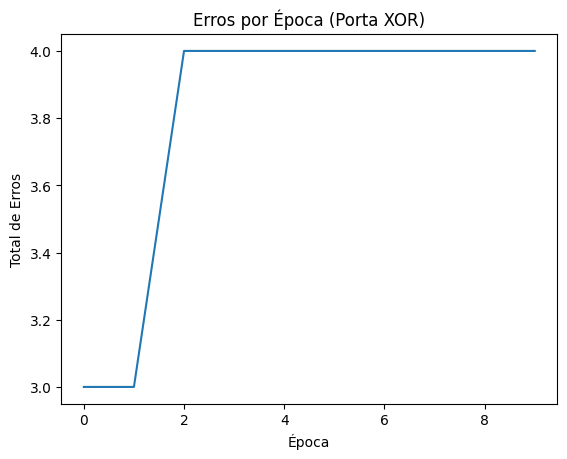

Nota: O erro não zera pois o Perceptron só resolve problemas linearmente separáveis.


In [9]:
# Dados do XOR (Não linearmente separável)
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])

# Criando e treinando
neuronio_xor = Perceptron(n_inputs=2, taxa_aprendizado=0.1, epocas=10)
neuronio_xor.fit(X_xor, y_xor)

# Visualizando o erro
plt.plot(neuronio_xor.historico_erros)
plt.title("Erros por Época (Porta XOR)")
plt.xlabel("Época")
plt.ylabel("Total de Erros")
plt.show()

print("Nota: O erro não zera pois o Perceptron só resolve problemas linearmente separáveis.")